In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [10]:
df = pd.read_csv("Churn_Feature_Engineered.csv")

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TenureGroup,RevenueCategory,AvgChargePerMonth,TotalServices,ChargeCategory,CustomerValueScore,ContractRisk,AutoPayment,FiberOpticUser,SeniorHighChargeRisk
0,7590-VHVEG,Female,0,Yes,No,1,0,No phone service,0,0,...,0-1 Year,Normal Revenue,14.925000,1,Low,29.85,3,0,0,0.0
1,5575-GNVDE,Male,0,No,No,34,1,No,0,1,...,2-4 Years,Normal Revenue,53.985714,3,Medium,1936.30,2,0,0,0.0
2,3668-QPYBK,Male,0,No,No,2,1,No,0,1,...,0-1 Year,Normal Revenue,36.050000,3,Medium,107.70,3,0,0,0.0
3,7795-CFOCW,Male,0,No,No,45,0,No phone service,0,1,...,2-4 Years,Normal Revenue,40.016304,3,Medium,1903.50,2,1,0,0.0
4,9237-HQITU,Female,0,No,No,2,1,No,0,0,...,0-1 Year,Normal Revenue,50.550000,1,High,141.40,3,0,0,0.0


In [12]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureGroup', 'RevenueCategory', 'AvgChargePerMonth', 'TotalServices',
       'ChargeCategory', 'CustomerValueScore', 'ContractRisk', 'AutoPayment',
       'FiberOpticUser', 'SeniorHighChargeRisk'],
      dtype='str')


In [13]:
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [14]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [15]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [16]:
X = pd.get_dummies(X, drop_first=True)

In [17]:
print(X.isnull().sum().sum())

print(y.isnull().sum())

0
0


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

In [21]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7672107877927609
Precision: 0.6666666666666666
Recall   : 0.24598930481283424
F1 Score : 0.359375


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.96      0.86      1035
           1       0.67      0.25      0.36       374

    accuracy                           0.77      1409
   macro avg       0.72      0.60      0.61      1409
weighted avg       0.75      0.77      0.73      1409



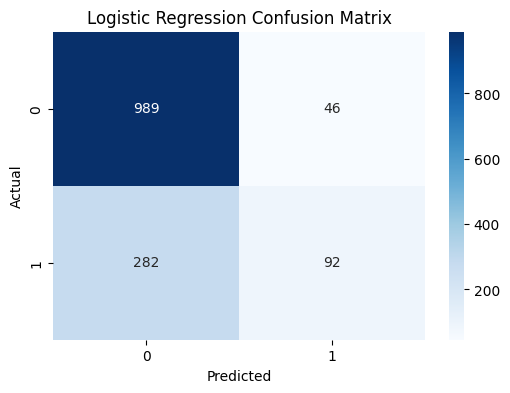

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(10)

,Feature,Coefficient
15,ContractRisk,0.553392
10,MonthlyCharges,0.461418
7070,PaymentMethod_Electronic check,0.421843
7068,PaperlessBilling_Yes,0.346400
2471,customerID_3512-IZIKN,0.202580
1532,customerID_2225-ZRGSG,0.197644
6112,customerID_8631-NBHFZ,0.192876
271,customerID_0378-XSZPU,0.189735
426,customerID_0607-DAAHE,0.188018
488,customerID_0687-ZVTHB,0.187151


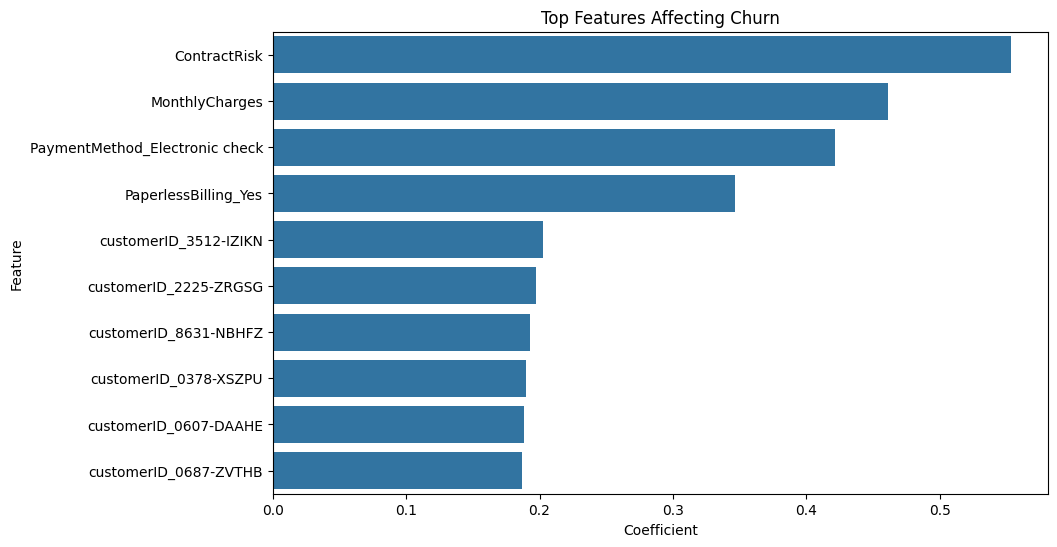

In [25]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title("Top Features Affecting Churn")

plt.show()

In [26]:
df.to_csv(
    "Churn_Model_Ready.csv",
    index=False
)